<a href="https://colab.research.google.com/github/ArifahZhafirah/PEMBELAJARAN-MESIN/blob/main/JS04/TUGAS/PEMMESTUGAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Deskripsi Dataset
Dataset yang digunakan adalah **insurance.csv**, yaitu dataset biaya asuransi kesehatan (medical insurance cost). Dataset ini berisi 1338 baris data peserta asuransi dengan variabel-variabel berikut:

- `age` : usia peserta (tahun)
- `sex` : jenis kelamin peserta (male/female)
- `bmi` : Body Mass Index, indeks massa tubuh peserta
- `children` : jumlah anak/tanggungan yang dicover oleh asuransi
- `smoker` : status merokok peserta (yes/no)
- `region` : wilayah tempat tinggal peserta di Amerika Serikat (northeast, northwest, southeast, southwest)
- `charges` : biaya medis personal yang ditagihkan oleh asuransi (variabel target)

In [1]:
# import package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# baca data dari file CSV
data = pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# mengecek ukuran, tipe data, dan statistik deskriptif
data.shape

(1338, 7)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
# mengecek apakah ada missing value
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


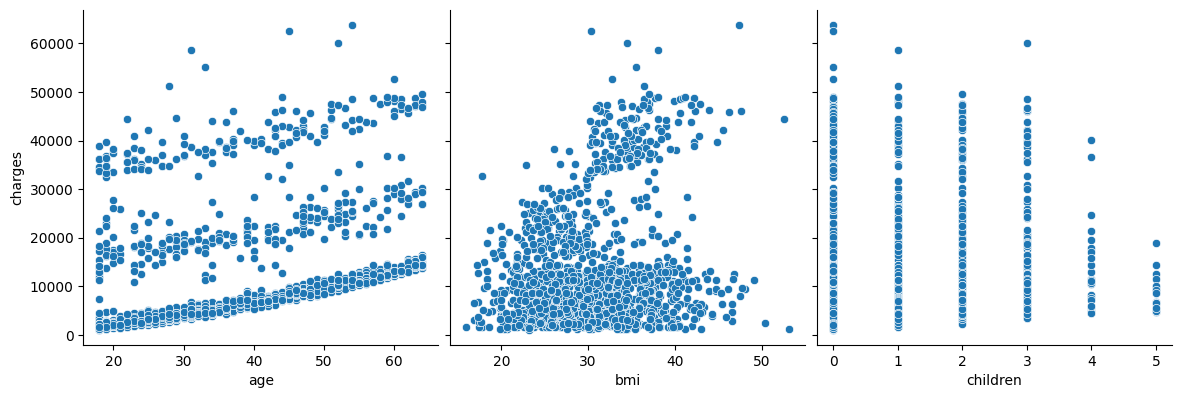

In [6]:
# visualisasi hubungan fitur numerik terhadap charges
sns.pairplot(data, x_vars=['age', 'bmi', 'children'],
             y_vars='charges', height=4, aspect=1, kind='scatter')
plt.show()

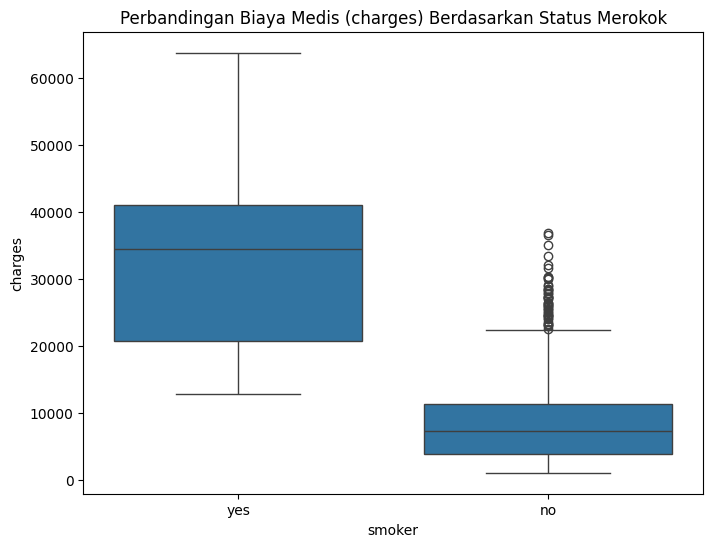

In [7]:
# visualisasi pengaruh status merokok terhadap biaya
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Perbandingan Biaya Medis (charges) Berdasarkan Status Merokok')
plt.show()

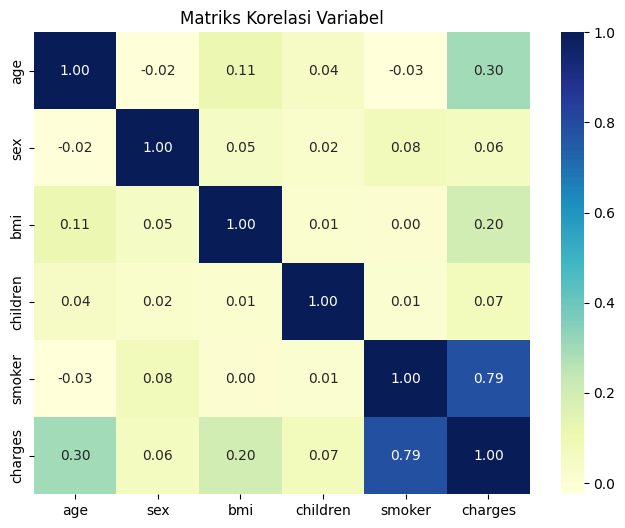

In [8]:
# encoding sementara khusus untuk keperluan heatmap korelasi
data_corr = data.copy()
data_corr['sex'] = data_corr['sex'].map({'male': 1, 'female': 0})
data_corr['smoker'] = data_corr['smoker'].map({'yes': 1, 'no': 0})

plt.figure(figsize=(8, 6))
sns.heatmap(data_corr.corr(numeric_only=True), cmap='YlGnBu', annot=True, fmt='.2f')
plt.title('Matriks Korelasi Variabel')
plt.show()

Dari heatmap terlihat bahwa variabel `smoker` memiliki korelasi paling kuat terhadap `charges`, diikuti oleh `age` dan `bmi`. Variabel `sex` dan `children` korelasinya relatif kecil terhadap `charges`.

#1. Identifikasi Variabel Bebas dan Variabel Target
Variabel target (label) yang akan diprediksi adalah `charges` (biaya medis personal). Variabel `sex`, `smoker`, dan `region` berupa data kategorikal, sehingga perlu diubah menjadi bentuk numerik menggunakan one-hot encoding (`pd.get_dummies`) sebelum digunakan sebagai variabel bebas (fitur).

In [9]:
# encoding variabel kategorikal menjadi numerik
data_encoded = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)
data_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [10]:
# Membuat variabel bebas X dan variabel target y
X = data_encoded.drop('charges', axis=1)
y = data_encoded['charges']

print('Fitur (X):', X.columns.tolist())
print('Target (y): charges')

Fitur (X): ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
Target (y): charges


#2. Split Data Latih dan Data Uji
Bagi data menjadi data latih (80%) dan data uji (20%) menggunakan `train_test_split`.

In [11]:
# Pembagian data latih dan data uji dengan proporsi 8:2
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=100)

print(f'Jumlah data latih: {X_train.shape[0]}')
print(f'Jumlah data uji: {X_test.shape[0]}')

Jumlah data latih: 1070
Jumlah data uji: 268


#3. Feature Scaling
Lakukan penskalaan fitur menggunakan `StandardScaler`. Feature scaling diperlukan karena rentang nilai antar fitur berbeda cukup jauh (contoh: `age` puluhan, `bmi` puluhan, sedangkan hasil encoding hanya bernilai 0/1), dan sangat penting terutama untuk model SVR yang sensitif terhadap skala data.

In [12]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

#4. Membuat Model Multiple Linear Regression
Buat model regresi linier berganda menggunakan Scikit-Learn.

In [13]:
# Membuat model Multiple Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

#5. Melatih Model dan Melakukan Prediksi
Latih model pada data latih, kemudian lakukan prediksi pada data uji.

In [14]:
# Training model pada data latih
lr.fit(X_train_scaled, y_train)

print('Intercept:', lr.intercept_)
print('Koefisien:')
for fitur, koef in zip(X.columns, lr.coef_):
    print(f'  {fitur}: {koef:.2f}')

Intercept: 13064.896362831774
Koefisien:
  age: 3716.45
  bmi: 1919.16
  children: 562.80
  sex_male: 6.31
  smoker_yes: 9347.49
  region_northwest: -174.23
  region_southeast: -409.49
  region_southwest: -479.88


In [15]:
# Prediksi pada data uji
y_pred_lr = lr.predict(X_test_scaled)
y_pred_lr[:5]

array([ 4330.17451273,  4432.55841612,  8465.47285821,  2810.39744495,
       24747.75879367])

#6. Evaluasi Model
Evaluasi model menggunakan R-squared, MSE, dan MAE.

In [16]:
# Evaluasi model
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print('=== Evaluasi Model Multiple Linear Regression ===')
print(f'R-squared : {r2_lr:.4f}')
print(f'MSE       : {mse_lr:.2f}')
print(f'RMSE      : {rmse_lr:.2f}')
print(f'MAE       : {mae_lr:.2f}')

=== Evaluasi Model Multiple Linear Regression ===
R-squared : 0.7947
MSE       : 32193193.04
RMSE      : 5673.90
MAE       : 3916.44


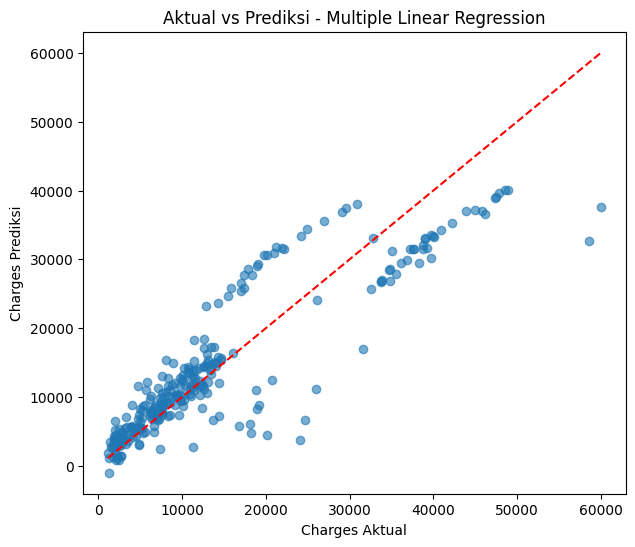

In [17]:
# Visualisasi data aktual vs data hasil prediksi
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Charges Aktual')
plt.ylabel('Charges Prediksi')
plt.title('Aktual vs Prediksi - Multiple Linear Regression')
plt.show()

#7. Model SVR (Support Vector Regression)
Ulangi langkah 4 dengan menggunakan model SVR kernel RBF, lalu bereksperimen dengan hyperparameter tuning. Karena SVR sensitif terhadap skala data, variabel target `y` juga perlu discaling menggunakan `StandardScaler`, dan hasil prediksi dikembalikan ke skala aslinya dengan `inverse_transform`.

In [18]:
# Feature scaling khusus untuk SVR (X dan y)
sc_y = StandardScaler()
y_train_scaled = sc_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# Membuat dan melatih model SVR (parameter default)
from sklearn.svm import SVR

svr_default = SVR(kernel='rbf')
svr_default.fit(X_train_scaled, y_train_scaled)

# Prediksi pada data uji, kembalikan ke skala asli
y_pred_svr_default_scaled = svr_default.predict(X_test_scaled)
y_pred_svr_default = sc_y.inverse_transform(y_pred_svr_default_scaled.reshape(-1, 1)).ravel()

r2_default = r2_score(y_test, y_pred_svr_default)
mse_default = mean_squared_error(y_test, y_pred_svr_default)
mae_default = mean_absolute_error(y_test, y_pred_svr_default)

print('=== Evaluasi Model SVR (parameter default) ===')
print(f'R-squared : {r2_default:.4f}')
print(f'MSE       : {mse_default:.2f}')
print(f'MAE       : {mae_default:.2f}')

=== Evaluasi Model SVR (parameter default) ===
R-squared : 0.8812
MSE       : 18627350.82
MAE       : 2495.26


In [19]:
# Hyperparameter tuning SVR dengan GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': ['scale', 0.01, 0.1],
    'epsilon': [0.01, 0.1, 0.5]
}

grid_svr = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_svr.fit(X_train_scaled, y_train_scaled)

print('Parameter terbaik:', grid_svr.best_params_)
print('Skor R2 rata-rata (cross validation):', grid_svr.best_score_)

Parameter terbaik: {'C': 100, 'epsilon': 0.1, 'gamma': 0.01}
Skor R2 rata-rata (cross validation): 0.8269564062597722


In [20]:
# Evaluasi model SVR dengan parameter terbaik hasil tuning
best_svr = grid_svr.best_estimator_

y_pred_svr_scaled = best_svr.predict(X_test_scaled)
y_pred_svr = sc_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print('=== Evaluasi Model SVR (setelah tuning) ===')
print(f'R-squared : {r2_svr:.4f}')
print(f'MSE       : {mse_svr:.2f}')
print(f'RMSE      : {rmse_svr:.2f}')
print(f'MAE       : {mae_svr:.2f}')

=== Evaluasi Model SVR (setelah tuning) ===
R-squared : 0.8820
MSE       : 18509086.88
RMSE      : 4302.22
MAE       : 2545.12


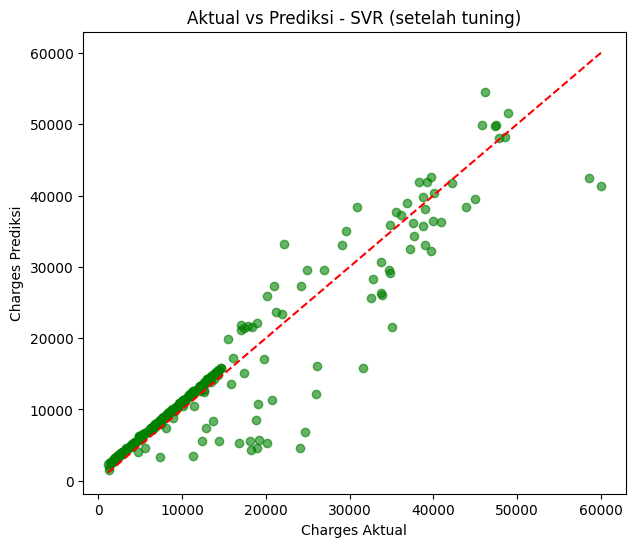

In [21]:
# Visualisasi data aktual vs data hasil prediksi - SVR
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Charges Aktual')
plt.ylabel('Charges Prediksi')
plt.title('Aktual vs Prediksi - SVR (setelah tuning)')
plt.show()

#Analisis Hasil

In [22]:
# Perbandingan hasil evaluasi kedua model
perbandingan = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'SVR (default)', 'SVR (tuned)'],
    'R-squared': [r2_lr, r2_default, r2_svr],
    'MSE': [mse_lr, mse_default, mse_svr],
    'MAE': [mae_lr, mae_default, mae_svr]
})
perbandingan

,Model,R-squared,MSE,MAE
0,Multiple Linear Regression,0.794697,3.219319e+07,3916.437776
1,SVR (default),0.881209,1.862735e+07,2495.264105
2,SVR (tuned),0.881963,1.850909e+07,2545.117714


Dari tabel perbandingan di atas, bisa dilihat kalau SVR (baik yang default maupun yang sudah di-tuning) hasilnya lebih bagus dibanding Multiple Linear Regression, R-squared-nya lebih tinggi dan error-nya (MSE, MAE) lebih kecil. Menurut saya ini masuk akal karena hubungan antar variabel di data ini sebenarnya tidak linear-linear banget. Contohnya biaya orang yang merokok itu naiknya jauh lebih drastis dibanding yang nggak merokok, apalagi kalau BMI-nya juga tinggi, jadi ada semacam efek gabungan yang bikin biayanya melonjak. Model linear regression cuma bisa narik garis lurus, jadi dia agak kesulitan menangkap pola kayak gini. SVR dengan kernel RBF lebih fleksibel karena bisa membentuk pola non-linear, makanya prediksinya lebih dekat ke nilai aslinya.

Untuk bagian tuning pakai GridSearchCV, hasilnya memang naik sedikit dibanding SVR default, parameter terbaik yang ketemu (C, gamma, epsilon) sedikit lebih pas buat data ini. Tapi peningkatannya nggak terlalu signifikan, jadi kelihatannya parameter default SVR di kasus ini sudah lumayan mendekati optimal, mungkin karena rentang parameter yang saya coba juga belum terlalu lebar.

Kalau dilihat dari koefisien dan korelasinya, variabel `smoker` paling berpengaruh besar ke `charges`, disusul `age` dan `bmi`. Sedangkan `sex`, `children`, dan `region` pengaruhnya kecil banget, jadi kalau mau nyederhanain model kedepannya, tiga variabel itu mungkin bisa dipertimbangkan untuk dikurangi.